# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 7</span>

### Exercise 07.1

Use the Monte Carlo NVT code we have provided to print out instantaneous values of potential energy per particle, $U/N$, and pressure, $P$, along **equilibrated** Monte Carlo simulations (of  $M=10^5$ MC steps and where the Metropolis acceptance ratio has been fixed approximately to 50%) in the following thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r_c = 2.2$)
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r_c = 5.0$)

1. <span style="color:red">Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ and $P$ to obtain the Monte Carlo correlation time</span> via a fit with an exponential function. This will suggest you how large should be the blocks in your simulations.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ and $P$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Exercise 07.2

<span style="color:red">Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the Monte Carlo NVT code</span> we have provided: average value of $g(r)$ in each block (with output in the file: output.gofr.0), final average value of $g(r)$ with statistical uncertainties (with output in the file: output.gave.0).

### Exercise 07.3

<span style="color:red">Include the calculation of the radial distribution function, $g(r)$, inside the previously used Molecular Dynamics code</span>.

### Exercise 07.4

By means of your upgraded MC code, equilibrate and <span style="color:red">perform MC NVT simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) and Krypton ($\sigma = 0.364$ nm, $\epsilon/k_B = 164$ K, $m=83.798$ amu) in the following conditions:
1. solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r_c = 2.2$)
2. liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)
3. gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r_c = 5.0$)

<span style="color:red">show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in SI units ... and compare your MC results for the radial distribution function, $g(r)$, with those obtained with Molecular Dynamics NVE simulations in similar thermodynamic conditions.</span>

# The End Goal of NVT Monte Carlo Simulation #
----------

In this exercise we are simulating a system of particles in the NVT canonical ensemble (constant number $N$ of particles, volume $V$ and temperature $T$). Before we delve into the solution let's pause and think about the end goal of simulations based on probabilistic properties such as statistical mechanics and thermodynamics.

## Statistical Mechanics ##

Statistical mechanics draws a bridge between the microscopic quantities of elements of a system, and the macroscopic properites of the entire system. The macroscopic properties of a system are in fact averages of the microscopic properties of its elements.

## Computer Simulations ##

Computer simulations complete the scientific method by adding an additional layer of knowledge. It cannot, however, substitute a real-life experiment to confirm an hypothesis. So what are computer simulations good for?

While - in the case of this exercise - the aim is purely academic (the results can be obtained analytically), in industrial/ research applications computer simulations can bring valuable insight. For example, they are often used to _design_ a real-life experiment. In fact, some experiments aimed to test physical hypothesis are very expensive to build and/or run (CERN collider, Tokamak, etc.). In these cases computer simulations are often used to get initial insights of the results or to optimize the experiment itself.

When simulating a system with a numerical simulation, it is therefore crucial to use a model as close as possible to the laws of physics governing the real system. Alternatively, one must control the numerical model's limitations and account for error. 

In this exercice, we are going to use a more physically accurate model as the one used in exercise 4 to simulate a system of particles.

# SOLUTION #
----------

## Metropolis Algorithm to Move the Particles ##

In this exercise we are going to simulate the same molecular system as in exercise 4, but by taking a different approach. Specifically, we are going to use the Metropolis algorithm in the function ```Move()``` to make the system evolve, instead of the Verlet algorithm.

Our new ```Move()``` function performs one Monte Carlo sweep of attempted moves: it attempts ```npart``` single-particle displacements. Each attempt picks a particle, proposes a small random displacement for that particle, evaluates the energy change, and accepts or rejects the move using the Metropolis criterion. ```accepted``` and ```attempted``` are counters used to compute the acceptance rate.

### ```Move()``` workflow ###

1. Picks a particle at random
2. Propose a new small random displacement (with amplitude $\delta$)
3. Compute the potential energy change: <br>
   $\Delta E = E_{new} - E_{old}$
4. Accept or reject using the Metropolis algorithm: <br>
   $$
        P_{\text{accept}} = \min\left(1, e^{-\beta \Delta E}\right)
   $$

    That is:

   - $\Delta E \le 0$ we **always** accept the move
   - $\Delta E > 0$ we accept the move with probability $P_{\text{accept}}$
   - Reject otherwise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Python’s built-in way to do shell-like file management safely and portably.
import shutil

# Subprocess: part of Python’s standard library. Allows to run external commands and programs from within the Python code.
import subprocess

# Third-party library to display progress bars
import tqdm as tqdm

# clear_output is used in Jupyter notebooks or IPython environments to clear the current cell’s output.
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

sns.set_theme(font_scale=1.7, style='whitegrid')

### Python Automation Script ###

Below is the Python automation script that orchestrates the execution of the simulation for three physical phases: solid, liquid, and gas. It uses shell commands to build and run the C++ program multiple times, changing its input each time.

<u>Note</u>:

The line ```subprocess.run(["make", "clean"], cwd=path, check=True)``` runs system command (make clean) using Python’s subprocess module, but in a **safe, structured way**. In fact, it passes a list of shell commands to be run, on **only the commands in the list**, by doing so it avoids accidentaly injecting and executing dangerous shell commands, such as recursive deletions.

In [2]:
path = "./Monte_Carlo_NVT/"
instant = []

ist_files = ["output_solid.dat", "output_liquid.dat", "output_gas.dat"]
inp_files = ["input.solid", "input.liquid", "input.gas"]
phase = ['Solid', 'Liquid', "Gas"]
colors = ['orange', 'red', 'purple']

In [3]:


print('-----------------------------------------------------')
print("Executing 500'000 steps of Monte Carlo Markov Chain")
print("Running the simulation 3 times for 3 different inputs:")
print("(solid, liquid, gas)")
print("-----------------------------------------------------")

for i in range(3):
    phase_name = phase[i]
    input_file = os.path.join(path, inp_files[i])
    output_file = os.path.join(path, ist_files[i])
    temp_input = os.path.join(path, "input.dat")
    temp_output = os.path.join(path, "istant_output.dat")

    print(f"Running program for {phase_name}...")

    # Copying the correct input file
    shutil.copy(input_file, temp_input)

    # Removing old output file
    if os.path.exists(output_file):
        os.remove(output_file)

    # Cleaning and rebuilding the program
    subprocess.run(["make", "clean"], cwd=path, check=True)
    subprocess.run(["make"], cwd=path, check=True)

    # Running the simulation executable
    subprocess.run(["./MC_NVT"], cwd=path, check=True)

    # Saving the output under the correct filename
    shutil.copy(temp_output, output_file)

print("Program terminated successfully.")

-----------------------------------------------------
Executing 500'000 steps of Monte Carlo Markov Chain
Running the simulation 3 times for 3 different inputs:
(solid, liquid, gas)
-----------------------------------------------------
Running program for Solid...
rm -f MC_NVT.o random.o MC_NVT istant_output.dat
c++    -c -o MC_NVT.o MC_NVT.cpp
c++    -c -o random.o random.cpp
g++ MC_NVT.o random.o -o MC_NVT
Read initial configuration from file config.0 

Initial potential energy (with tail corrections) = -8.71336
Virial                   (with tail corrections) = 0.337311
Pressure                 (with tail corrections) = 1.25104


--------------------------------------------------------------------------------------------
(restart=="true") Equilibration phase. Running 10000 steps to equilibrate the system

Equilibration step 0
Equilibration step 250
Equilibration step 500
Equilibration step 750
Equilibration step 1000
Equilibration step 1250
Equilibration step 1500
Equilibration step

### Instantaneous $U/N$ and $P$ along equilibrated MC simulations ###
-----------
- steps: $M=10^5$
- Metropolis acceptance rate: $\approx 50\%$
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r_c = 2.2$), (amplitude $\delta_s = 0.11$)
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$), (amplitude $\delta_l = 0.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r_c = 5.0$), (amplitude$\delta_g = 5.0$)

In [4]:
for i in range(3):
    instant.append(np.loadtxt(path+ist_files[i]))

In [5]:
len_ist = len(instant)

def plot_equilibration(mylist, steps, idx, title, col1, col2):
    plt.figure(figsize=(18,6))
    plt.suptitle(title)
    
    plt.subplot(1,2,1)
    plt.plot(mylist[idx].T[0][:steps], color=col1, linewidth=3, alpha=0.5, label='Energy')
    plt.xlabel('steps')
    plt.ylabel('U/N [LJ units]')
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(mylist[idx].T[2][:steps], color=col2, linewidth=3, alpha=0.5, label='Pressure')
    plt.xlabel('steps')
    plt.ylabel('P [LJ units]')
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.legend()
    
    plt.tight_layout()
    
def plot_final(mylist, steps, idx, title, col1, col2):
    plt.figure(figsize=(18,6))
    plt.suptitle(title)

    total_steps = len(mylist[idx].T[0])
    x = range(total_steps - steps, total_steps)
    
    plt.subplot(1,2,1)
    plt.plot(x, mylist[idx].T[0][-steps:], color=col1, linewidth=3, alpha=0.5, label='Energy')
    plt.xlabel('steps')
    plt.ylabel('U/N [LJ units]')
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(x, mylist[idx].T[2][-steps:], color=col2, linewidth=3, alpha=0.5, label='Pressure')
    plt.xlabel('steps')
    plt.ylabel('P [LJ units]')
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.legend()
    
    plt.tight_layout()

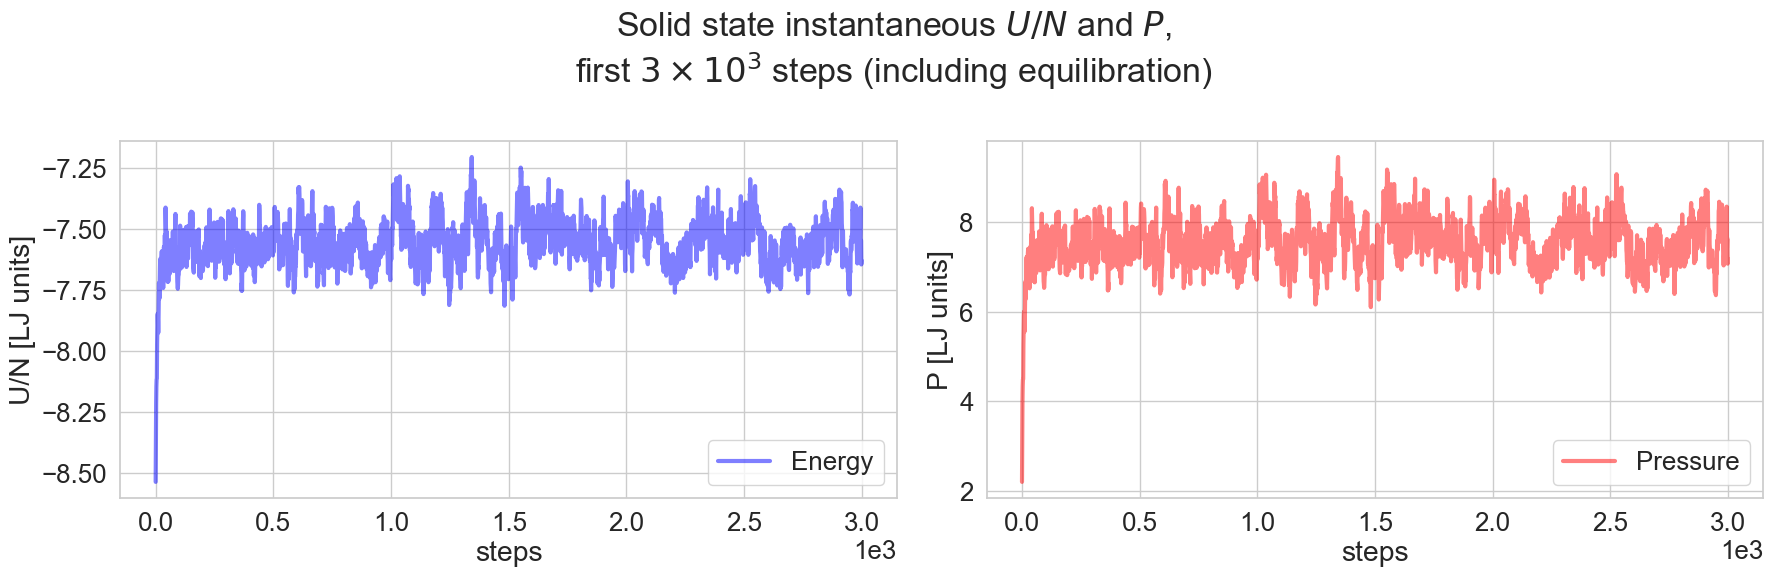

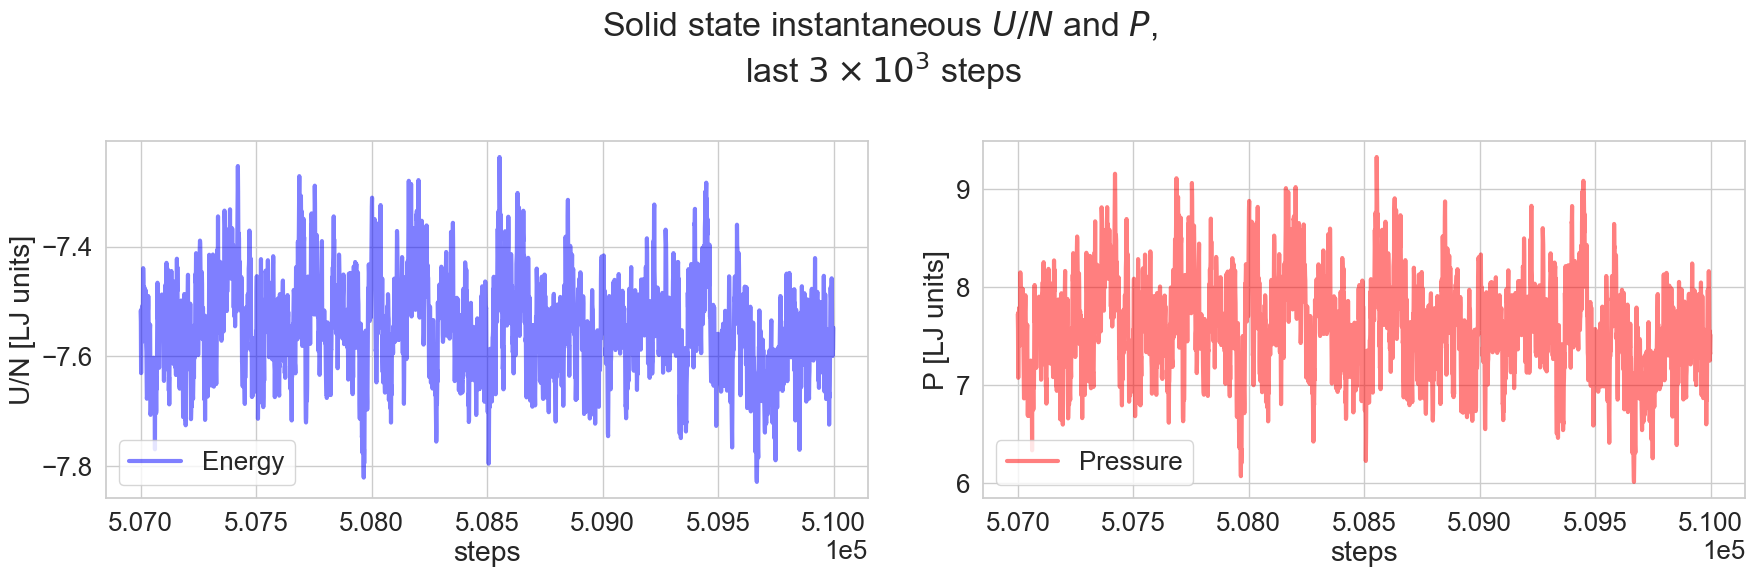

In [6]:
title_1 = "Solid state instantaneous $U/N$ and $P$,\nfirst $3 \\times 10^3$ steps (including equilibration)"
plot_equilibration(instant, 3000, 0, title_1, 'blue', 'red')
title_2 = "Solid state instantaneous $U/N$ and $P$,\n last $3 \\times 10^3$ steps"
plot_final(instant, 3000, 0, title_2, 'blue', 'red')

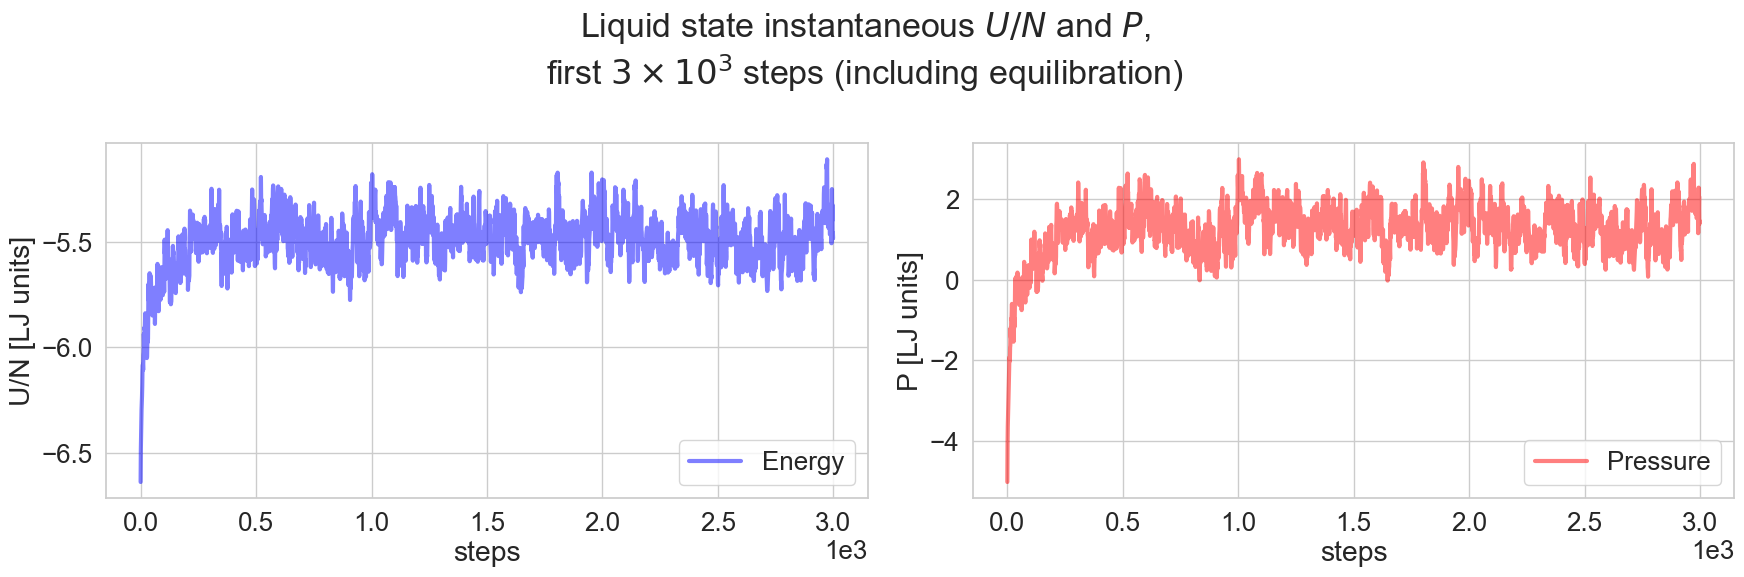

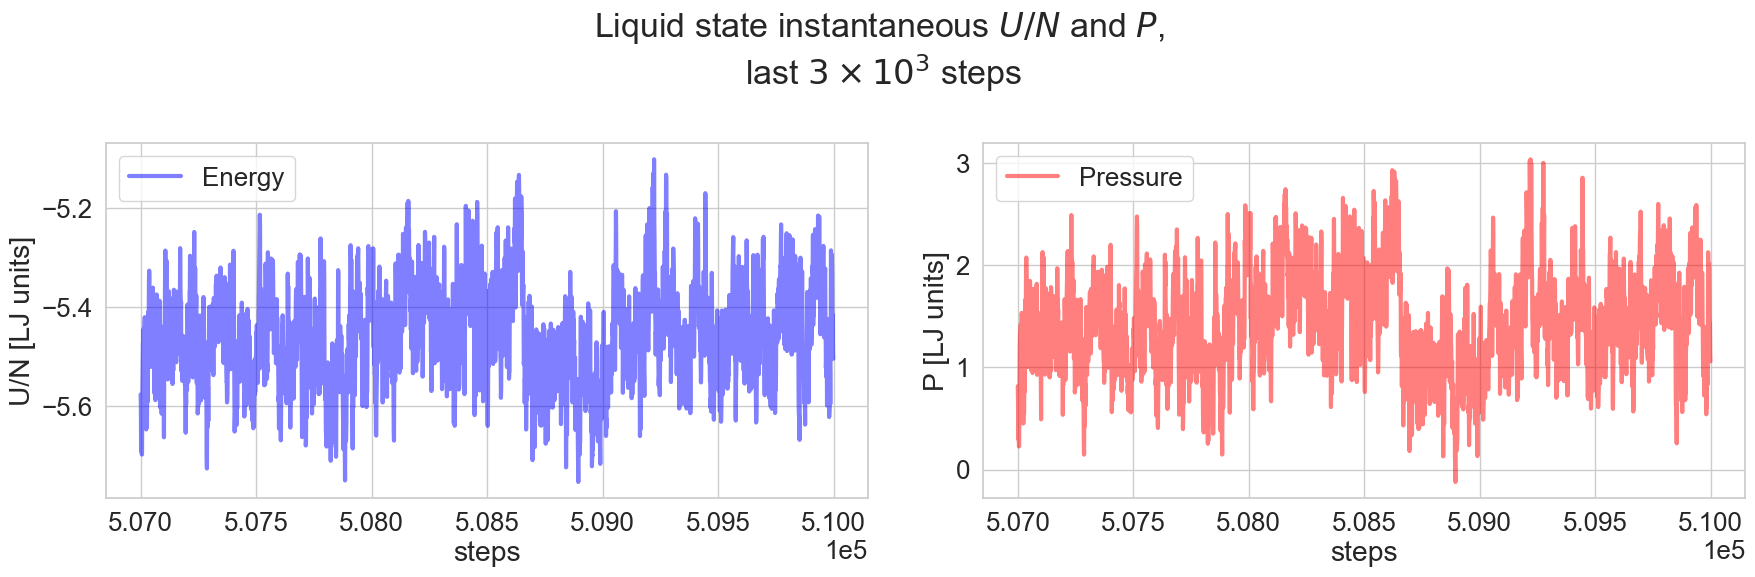

In [7]:
title_3 = "Liquid state instantaneous $U/N$ and $P$,\nfirst $3 \\times 10^3$ steps (including equilibration)"
plot_equilibration(instant, 3000, 1, title_3, 'blue', 'red')
title_4 = "Liquid state instantaneous $U/N$ and $P$,\n last $3 \\times 10^3$ steps"
plot_final(instant, 3000, 1, title_4, 'blue', 'red')

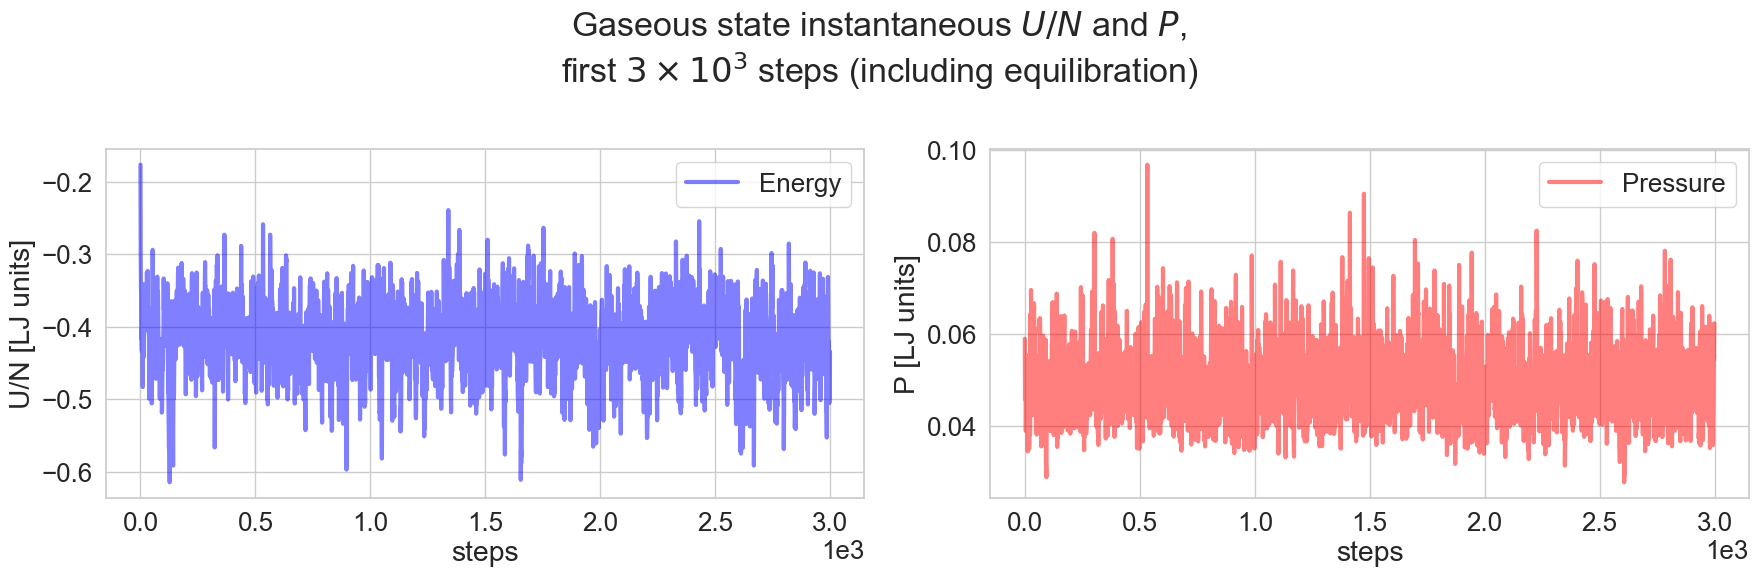

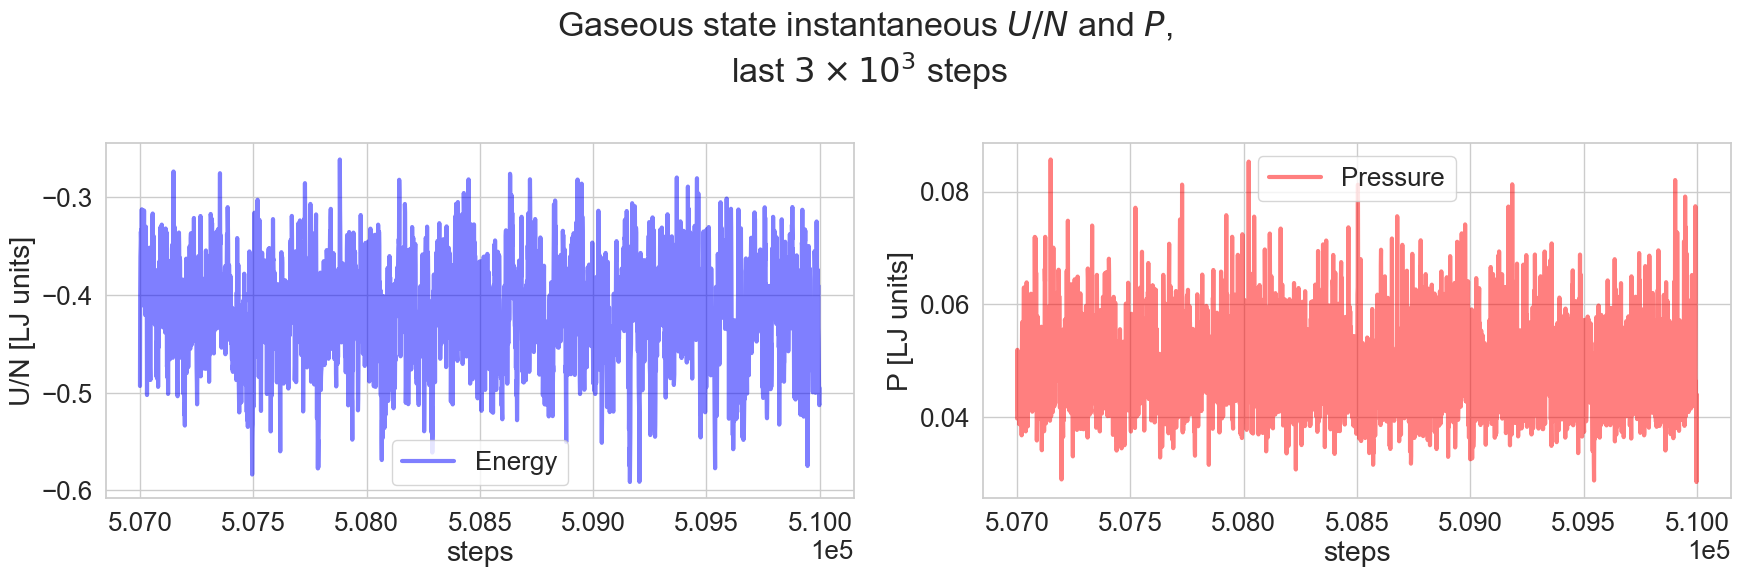

In [8]:
title_5 = "Gaseous state instantaneous $U/N$ and $P$,\nfirst $3 \\times 10^3$ steps (including equilibration)"
plot_equilibration(instant, 3000, 2, title_5, 'blue', 'red')
title_6 = "Gaseous state instantaneous $U/N$ and $P$,\n last $3 \\times 10^3$ steps"
plot_final(instant, 3000, 2, title_6, 'blue', 'red')

## Autocorrelation Time $\tau$ ##
-----------

One of the main drawbacks of the Metropolis algorithm is the strong correlation between consecutive configurations, since each step depends on the previous one. This correlation reduces the number of statistically independent samples and can lead to underestimated uncertainties in the computed mean values.

However, increasing the sample size generally reduces the effect of correlation on statistical estimates. At the same time, using fewer samples increases statistical uncertainty. To find a balance between minimizing autocorrelation and maintaining reasonable statistical errors, we compute the autocorrelation time, which indicates after how many steps the data can be considered effectively uncorrelated.

Let $AC(\tau)$ be the Autocorrelation function, defined as:

$$
AC_U(\tau) =
\frac{
\frac{1}{N-\tau} \sum_{t=0}^{N-\tau-1} U_{t} U_{t+\tau}
-
\left( \frac{1}{N-\tau} \sum_{t=0}^{N-\tau-1} U_t \right)
\left( \frac{1}{N-\tau} \sum_{t=0}^{N-\tau-1} U_{t+\tau} \right)
}
{\mathrm{var}(U)}
$$

$$
AC_U(\tau) =
\frac{\langle U_t U_{t+\tau} \rangle - \langle U \rangle^2}{\mathrm{var}(U)}
=
\frac{\langle U_t U_{t+\tau} \rangle - \langle U \rangle^2}{\langle U^2 \rangle - \langle U \rangle^2}
$$

In general, the autocorrelation time gives the following information:

- If $AC(t)$ is close to 1, then the values separated by $\tau$ steps are highly correlated.
- If $AC(t)$ is close to 0, then the values separated by $\tau$ steps are almost independent.

And so the **Monte Carlo correlation time $\tau$** is the time for $AC(t)$ to decay exponentially near 0. It tells us how many steps do we need to take to make independent measurements; in practice, it tells us what the size of our blocks should be.

To determine $\tau$, we can fit $AC(\tau)$ with:

$$
\displaystyle
AC(\tau)= exp(-t/\tau)
$$

In the next script we'll find $\tau$. We start by removing the equilibration steps ($10^3$ steps) from the calculation.

In [9]:
energies  = []
pressures = []

for i in range(3):
    energies.append(instant[i].T[0][10000:])
    pressures.append(instant[i].T[2][10000:])

In [10]:
N = len(energies[i])    # 500'000

In [11]:
AC_U = []
AC_P = []

npoints = 500

for i in range(3):
    print(phase[i] + " phase autocorrelation function")
    ac_u = []
    ac_p = []

    for tau in tqdm.tqdm(range(npoints)):
        U_minus_tau = energies[i][:N - tau]       
        P_minus_tau = pressures[i][:N - tau]
        U_plus_tau = energies[i][tau:]          
        P_plus_tau = pressures[i][tau:]

        # t-tau = 500'000 - tau
        n = len(U_minus_tau)
        
        ac_u.append((sum(U_minus_tau * U_plus_tau)/n - sum(U_minus_tau) / n * sum(U_plus_tau) / n)   
                    / np.std(energies[i])**2)                                                        
        ac_p.append((sum(P_minus_tau * P_plus_tau)/n - sum(P_minus_tau) / n * sum(P_plus_tau) / n)
                    / np.std(pressures[i])**2)
        
    AC_U.append(ac_u)
    AC_P.append(ac_p)

Solid phase autocorrelation function


100%|█████████████████████████████████████████| 500/500 [01:04<00:00,  7.76it/s]


Liquid phase autocorrelation function


100%|█████████████████████████████████████████| 500/500 [01:04<00:00,  7.70it/s]


Gas phase autocorrelation function


100%|█████████████████████████████████████████| 500/500 [01:05<00:00,  7.69it/s]


In [12]:
def plot_ac(idx, cut1, cut2, col1, col2, title):
    plt.figure(figsize=(18,6))
    plt.suptitle(title)
    
    plt.subplot(1,2,1)
    plt.title(r'AC values for all $\tau$')
    plt.plot(AC_U[idx], linewidth=3, color=col1, alpha=0.6, label='U/N')
    plt.plot(AC_P[idx], linewidth=3, color=col2, alpha=0.6, label='P')
    plt.axvspan(0, cut1, facecolor='black', alpha=0.15, label=r'$\tau$ to exclude')
    plt.xlabel(r'$\tau$')
    plt.ylabel(r'$AC(\tau)$')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.title(r'AC values $\tau$ after exclusion')
    plt.plot(np.arange(cut1,500), AC_U[idx][-(500-cut1):], linewidth=3, color=col1, alpha=0.6, label='U/N')
    plt.plot(np.arange(cut1,500), AC_P[idx][-(500-cut2):], linewidth=3, color=col2, alpha=0.6, label='P')
    plt.xlabel(r'$\tau$')
    plt.ylabel(r'$AC(\tau)$')
    plt.legend()
    plt.tight_layout()

    plt.show()

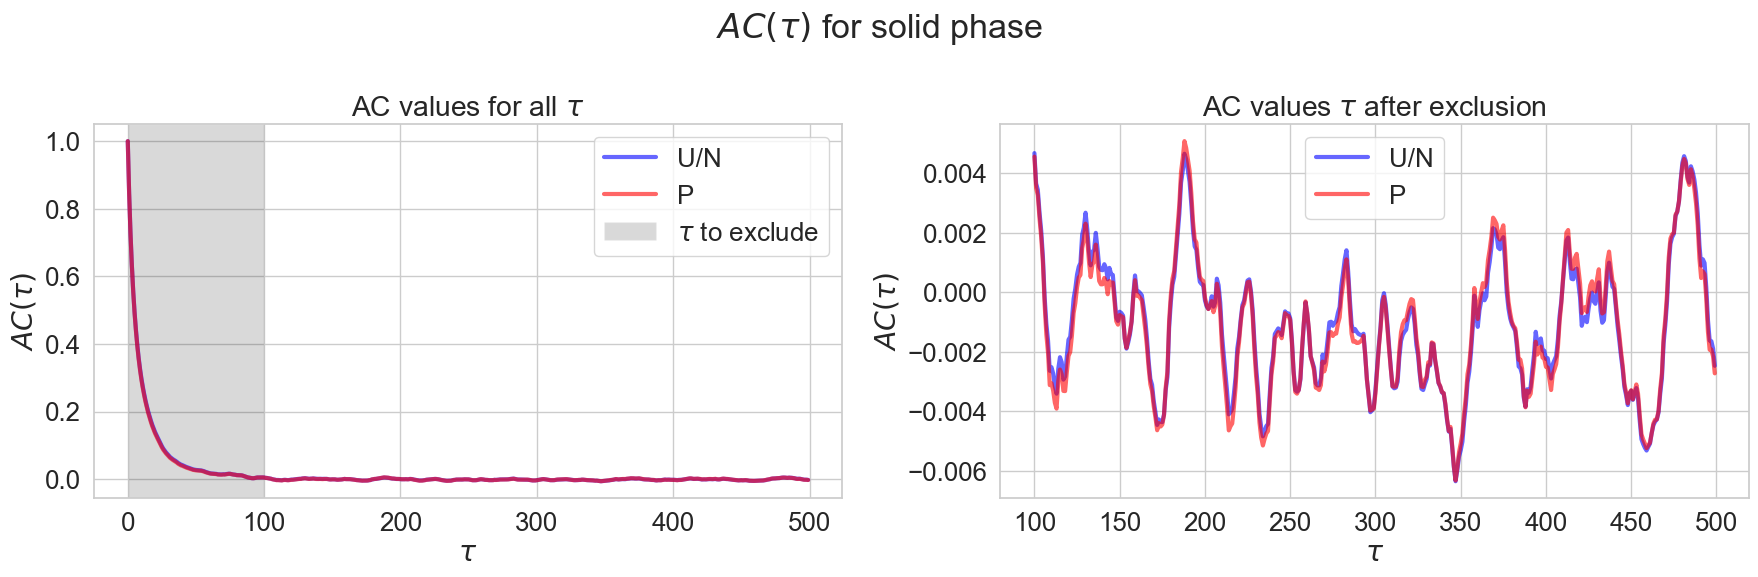

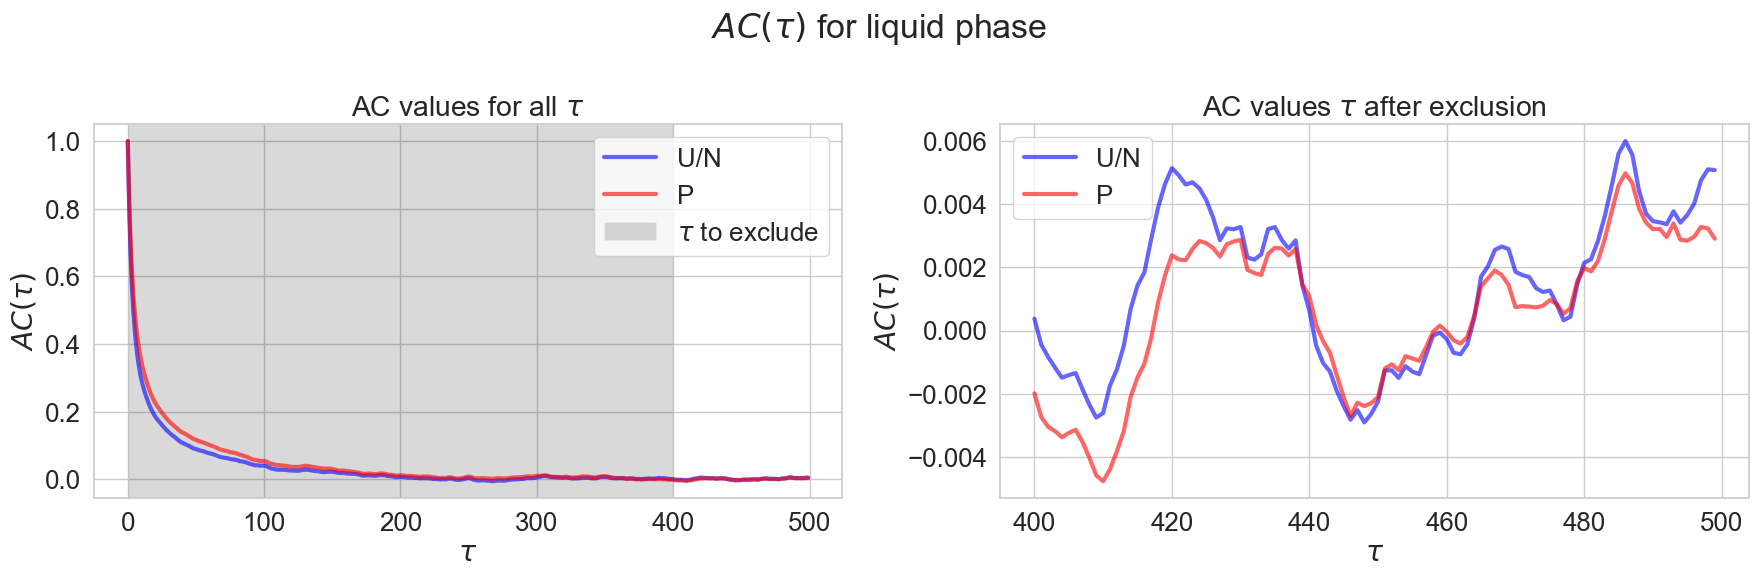

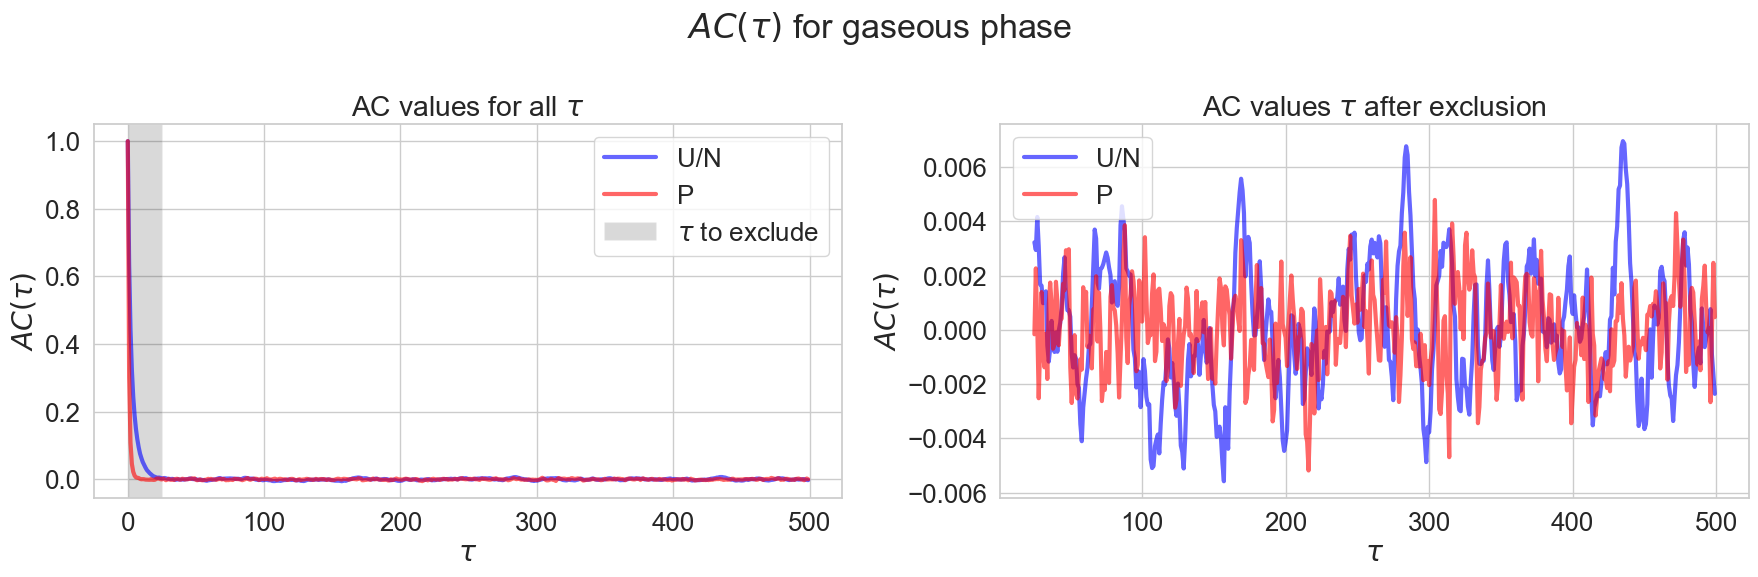

In [13]:
import matplotlib.pyplot as plt
plot_ac(0, 100, 100, 'blue', 'red', r'$AC(\tau)$ for solid phase')
plot_ac(1, 400, 400, 'blue', 'red', r'$AC(\tau)$ for liquid phase')
plot_ac(2, 25, 25, 'blue', 'red', r'$AC(\tau)$ for gaseous phase')

# The Radial Distribution Function $g(r)$ #
-----

The following script will automate the executions of our molecular Monte Carlo NVT simulation, one execution per phase (gas, liquid and solid). It will then save the relevant results in order to compute the **radial distribution function** $g(r)$.

## Expected Results ##

The radial distribution function tells us how particles are aranged around a reference particle (a "fixed" particle). What we expect to observe is the following:

- $g(r)=1$ typical of a gas
- $g(r)$ has broad peaks and a long tail: this configuration is typical of a liquid
- $g(r)$ has sharp peaks: ordered structure, like a crystal lattice

## Program Worflow ##

## Libraries Reload ##

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Python’s built-in way to do shell-like file management safely and portably.
import shutil

# Subprocess: part of Python’s standard library. Allows to run external commands and programs from within the Python code.
import subprocess

# Third-party library to display progress bars
import tqdm as tqdm

# clear_output is used in Jupyter notebooks or IPython environments to clear the current cell’s output.
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

sns.set_theme(font_scale=1.7, style='whitegrid')

In [18]:
import os
import shutil
import subprocess
from IPython.display import clear_output

path = "./Monte_Carlo_NVT/"

phase = ["Solid", "Liquid", "Gas"]
inp_files = ["input.solid", "input.liquid", "input.gas"]
gofr_files = ["gofr_NVT_solid.dat", "gofr_NVT_liquid.dat", "gofr_NVT_gas.dat"]

NVT_meas_U = []
NVT_err_U  = []
NVT_meas_P = []
NVT_err_P  = []

print('-----------------------------------------------------')
print("Executing 500,000 steps of Monte Carlo NVT simulation")
print("Running the simulation 3 times for 3 different inputs:")
print("(solid, liquid, gas)")
print("-----------------------------------------------------")

for i in range(3):
    phase_name = phase[i]
    input_file = os.path.join(path, inp_files[i])
    gofr_file  = os.path.join(path, gofr_files[i])
    temp_input = os.path.join(path, "input.dat")

    print(f"\nRunning program for {phase_name} phase...")
    print("---------------------------------------------------------")

    # Copy correct input file
    shutil.copy(input_file, temp_input)

    # Clean and rebuild
    subprocess.run(["make", "clean"], cwd=path, check=True)
    subprocess.run(["make"], cwd=path, check=True)

    # Run the NVT simulation executable
    subprocess.run(["./MC_NVT"], cwd=path, check=True)

    # Save the g(r) output
    shutil.copy(os.path.join(path, "output.gave.0"), gofr_file)

    # --- Read thermodynamic data ---
    epot = np.loadtxt(os.path.join(path, "output.epot.0")).T
    pres = np.loadtxt(os.path.join(path, "output.pres.0")).T

    NVT_meas_U.append(epot[2])  # potential energy per particle
    NVT_err_U.append(epot[3])   # error on U/N
    NVT_meas_P.append(pres[2])  # pressure
    NVT_err_P.append(pres[3])   # error on P

    clear_output(wait=True)

print("\nAll simulations completed successfully!")

r_range, gofr_NVT, err_NVT = [], [], []

for i in range(3):
    data = np.loadtxt(os.path.join(path, gofr_files[i])).T
    r_range.append(data[0])
    gofr_NVT.append(data[1])
    err_NVT.append(data[2])

print("Radial distribution functions loaded for all phases.")


All simulations completed successfully!
Radial distribution functions loaded for all phases.


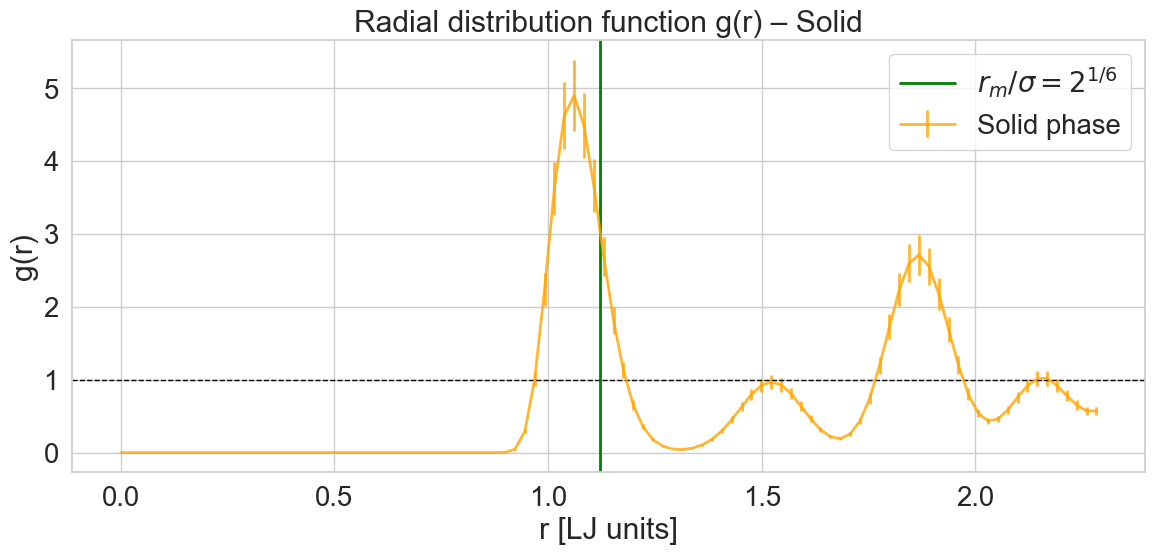

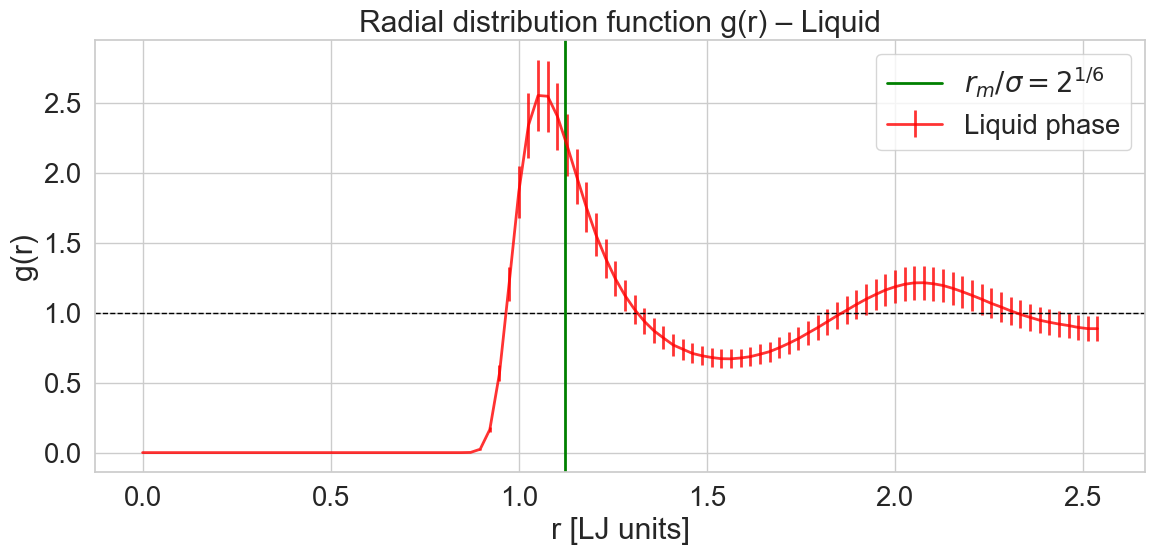

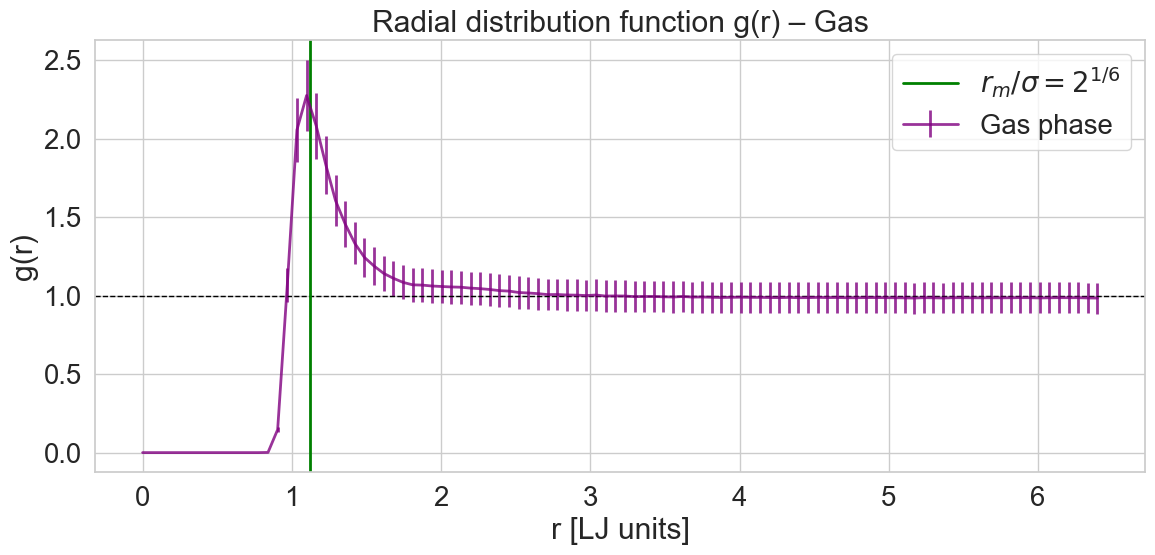

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "./Monte_Carlo_NVT/Saved_Results/"

NVT_files = [
    "gofr_NVT_solid.dat",
    "gofr_NVT_liquid.dat",
    "gofr_NVT_gas.dat"
]

phases = ["Solid", "Liquid", "Gas"]
colors = ["orange", "red", "purple"]

r_range = []
gofr_NVT = []
err_NVT = []

for fname in NVT_files:
    data = np.loadtxt(path + fname).T
    r_range.append(data[0])
    gofr_NVT.append(data[1])
    err_NVT.append(data[2])

sns.set_theme(font_scale=1.8, style='whitegrid')

for i in range(3):
    plt.figure(figsize=(12, 6))
    plt.errorbar(
        r_range[i], gofr_NVT[i], yerr=err_NVT[i],
        color=colors[i], linewidth=2, alpha=0.8,
        label=f"{phases[i]} phase"
    )

    plt.title(f"Radial distribution function g(r) – {phases[i]}")
    plt.xlabel("r [LJ units]")
    plt.ylabel("g(r)")
    plt.axhline(1, color='black', linestyle='--', linewidth=1)
    plt.axvline(2**(1/6), color='green', linestyle='-', linewidth=2,
                label=r"$r_m / \sigma = 2^{1/6}$")

    plt.legend()
    plt.tight_layout()
    plt.show()